# WW2 Weather Conditions - Regression Analysis

This project predicts daily mean temperature using maximum and minimum temperatures from a World War II weather dataset. The goal is to compare several linear regression models and evaluate their performance with common regression metrics.

## Overview
- Task: supervised regression
- Target: mean temperature
- Features: max temperature, min temperature
- Models: Linear Regression, Lasso, Ridge, ElasticNet, ElasticNetCV
- Metrics: MAE, MSE, R2

## Dataset
The dataset contains daily weather observations from World War II. It includes temperature readings and additional meteorological fields. Only the columns required for this experiment are used.

## Workflow
1. Load data and inspect basic structure.
2. Remove columns that are fully missing.
3. Drop columns with more than 70% missing values.
4. Remove remaining columns containing any missing values.
5. Parse date column and clean precipitation values.
6. Explore correlations and visualize heatmap.
7. Select features and target.
8. Split into train/test sets.
9. Apply standard scaling to numeric features.
10. Train multiple linear models and compare results.

## Feature Selection
- Input features: MaxTemp, MinTemp
- Target: MeanTemp

## Train/Test Split
- Train size: 20%
- Random state: 15

## Models
- Linear Regression
- Lasso Regression
- Ridge Regression
- ElasticNet
- ElasticNetCV (5-fold cross-validation)

## Evaluation Metrics
- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- R2 Score

## Results
Below is a template table for your final numbers. Replace the placeholders with the values shown in the notebook output.

| Model           | MAE    | MSE    | R2     |
|----------------|--------|--------|--------|
| Linear         | 0.1708 | 0.2661 | 0.9961 |
| Lasso          | 0.7451 | 1.3046 | 0.9810 |
| Ridge          | 0.1707 | 0.2661 | 0.9961 |
| ElasticNet     | 1.5194 | 4.8404 | 0.9294 |
| ElasticNetCV   | 0.1709 | 0.2676 | 0.9961 |

## Example Prediction
A simple example uses max temp = 30 and min temp = 20 to predict mean temperature after scaling.

## Visuals
- Correlation heatmap
- Boxplots before and after scaling
- Scatter plots of predicted vs. actual values for each model

## How To Run
1. Put the dataset CSV in the working directory.
2. Run the notebook from top to bottom.
3. Review printed metrics and plots.

## Notes
- StandardScaler is applied only to features.
- Regularized models are tested to evaluate stability and generalization.

## Acknowledgments
Dataset provided by Kaggle.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df = pd.read_csv("Summary of Weather.csv")

C:\Users\user\AppData\Local\Temp\ipykernel_8484\2360501030.py:1: DtypeWarning: Columns (0: Snowfall, 1: PoorWeather, 2: SNF, 3: TSHDSBRSGF) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Summary of Weather.csv")


In [3]:
df.head()

,STA,Date,Precip,WindGustSpd,MaxTemp,MinTemp,MeanTemp,Snowfall,PoorWeather,YR,...,FB,FTI,ITH,PGT,TSHDSBRSGF,SD3,RHX,RHN,RVG,WTE
0,10001,1942-7-1,1.016,NaN,25.555556,22.222222,23.888889,0.0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10001,1942-7-2,0,NaN,28.888889,21.666667,25.555556,0.0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,10001,1942-7-3,2.54,NaN,26.111111,22.222222,24.444444,0.0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,10001,1942-7-4,2.54,NaN,26.666667,22.222222,24.444444,0.0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,10001,1942-7-5,0,NaN,26.666667,21.666667,24.444444,0.0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.tail()

,STA,Date,Precip,WindGustSpd,MaxTemp,MinTemp,MeanTemp,Snowfall,PoorWeather,YR,...,FB,FTI,ITH,PGT,TSHDSBRSGF,SD3,RHX,RHN,RVG,WTE
119035,82506,1945-12-27,0,NaN,28.333333,18.333333,23.333333,0.0,NaN,45,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
119036,82506,1945-12-28,9.906,NaN,29.444444,18.333333,23.888889,0.0,1.0,45,...,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
119037,82506,1945-12-29,0,NaN,28.333333,18.333333,23.333333,0.0,1.0,45,...,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
119038,82506,1945-12-30,0,NaN,28.333333,18.333333,23.333333,0.0,NaN,45,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
119039,82506,1945-12-31,0,NaN,29.444444,17.222222,23.333333,0.0,NaN,45,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119040 entries, 0 to 119039
Data columns (total 31 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   STA          119040 non-null  int64  
 1   Date         119040 non-null  str    
 2   Precip       119040 non-null  str    
 3   WindGustSpd  532 non-null     float64
 4   MaxTemp      119040 non-null  float64
 5   MinTemp      119040 non-null  float64
 6   MeanTemp     119040 non-null  float64
 7   Snowfall     117877 non-null  object 
 8   PoorWeather  34237 non-null   object 
 9   YR           119040 non-null  int64  
 10  MO           119040 non-null  int64  
 11  DA           119040 non-null  int64  
 12  PRCP         117108 non-null  str    
 13  DR           533 non-null     float64
 14  SPD          532 non-null     float64
 15  MAX          118566 non-null  float64
 16  MIN          118572 non-null  float64
 17  MEA          118542 non-null  float64
 18  SNF          117877 non-null  objec

In [6]:
df.describe()

,STA,WindGustSpd,MaxTemp,MinTemp,MeanTemp,YR,MO,DA,DR,SPD,...,FT,FB,FTI,ITH,PGT,SD3,RHX,RHN,RVG,WTE
count,119040.000000,532.000000,119040.000000,119040.000000,119040.000000,119040.000000,119040.000000,119040.000000,533.000000,532.000000,...,0.0,0.0,0.0,0.0,525.000000,0.0,0.0,0.0,0.0,0.0
mean,29659.435795,37.774534,27.045111,17.789511,22.411631,43.805284,6.726016,15.797530,26.998124,20.396617,...,NaN,NaN,NaN,NaN,12.085333,NaN,NaN,NaN,NaN,NaN
std,20953.209402,10.297808,8.717817,8.334572,8.297982,1.136718,3.425561,8.794541,15.221732,5.560371,...,NaN,NaN,NaN,NaN,5.731328,NaN,NaN,NaN,NaN,NaN
min,10001.000000,18.520000,-33.333333,-38.333333,-35.555556,40.000000,1.000000,1.000000,2.000000,10.000000,...,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN
25%,11801.000000,29.632000,25.555556,15.000000,20.555556,43.000000,4.000000,8.000000,11.000000,16.000000,...,NaN,NaN,NaN,NaN,8.500000,NaN,NaN,NaN,NaN,NaN
50%,22508.000000,37.040000,29.444444,21.111111,25.555556,44.000000,7.000000,16.000000,32.000000,20.000000,...,NaN,NaN,NaN,NaN,11.600000,NaN,NaN,NaN,NaN,NaN
75%,33501.000000,43.059000,31.666667,23.333333,27.222222,45.000000,10.000000,23.000000,34.000000,23.250000,...,NaN,NaN,NaN,NaN,15.000000,NaN,NaN,NaN,NaN,NaN
max,82506.000000,75.932000,50.000000,34.444444,40.000000,45.000000,12.000000,31.000000,78.000000,41.000000,...,NaN,NaN,NaN,NaN,23.900000,NaN,NaN,NaN,NaN,NaN


In [7]:
df.shape

(119040, 31)

In [8]:
df.isnull().sum()

STA                 0
Date                0
Precip              0
WindGustSpd    118508
MaxTemp             0
MinTemp             0
MeanTemp            0
Snowfall         1163
PoorWeather     84803
YR                  0
MO                  0
DA                  0
PRCP             1932
DR             118507
SPD            118508
MAX               474
MIN               468
MEA               498
SNF              1163
SND            113477
FT             119040
FB             119040
FTI            119040
ITH            119040
PGT            118515
TSHDSBRSGF      84803
SD3            119040
RHX            119040
RHN            119040
RVG            119040
WTE            119040
dtype: int64

In [9]:
df.dropna(axis=1 ,how="all", inplace=True)

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119040 entries, 0 to 119039
Data columns (total 22 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   STA          119040 non-null  int64  
 1   Date         119040 non-null  str    
 2   Precip       119040 non-null  str    
 3   WindGustSpd  532 non-null     float64
 4   MaxTemp      119040 non-null  float64
 5   MinTemp      119040 non-null  float64
 6   MeanTemp     119040 non-null  float64
 7   Snowfall     117877 non-null  object 
 8   PoorWeather  34237 non-null   object 
 9   YR           119040 non-null  int64  
 10  MO           119040 non-null  int64  
 11  DA           119040 non-null  int64  
 12  PRCP         117108 non-null  str    
 13  DR           533 non-null     float64
 14  SPD          532 non-null     float64
 15  MAX          118566 non-null  float64
 16  MIN          118572 non-null  float64
 17  MEA          118542 non-null  float64
 18  SNF          117877 non-null  objec

In [11]:
df.isnull().sum()

STA                 0
Date                0
Precip              0
WindGustSpd    118508
MaxTemp             0
MinTemp             0
MeanTemp            0
Snowfall         1163
PoorWeather     84803
YR                  0
MO                  0
DA                  0
PRCP             1932
DR             118507
SPD            118508
MAX               474
MIN               468
MEA               498
SNF              1163
SND            113477
PGT            118515
TSHDSBRSGF      84803
dtype: int64

In [12]:
df = df.loc[:, df.isna().mean() < 0.70]


In [13]:
df.describe()

,STA,MaxTemp,MinTemp,MeanTemp,YR,MO,DA,MAX,MIN,MEA
count,119040.000000,119040.000000,119040.000000,119040.000000,119040.000000,119040.000000,119040.000000,118566.000000,118572.000000,118542.000000
mean,29659.435795,27.045111,17.789511,22.411631,43.805284,6.726016,15.797530,81.003745,64.273808,72.644843
std,20953.209402,8.717817,8.334572,8.297982,1.136718,3.425561,8.794541,14.869361,14.481498,14.211082
min,10001.000000,-33.333333,-38.333333,-35.555556,40.000000,1.000000,1.000000,-28.000000,-37.000000,-32.000000
25%,11801.000000,25.555556,15.000000,20.555556,43.000000,4.000000,8.000000,78.000000,59.000000,69.000000
50%,22508.000000,29.444444,21.111111,25.555556,44.000000,7.000000,16.000000,85.000000,70.000000,78.000000
75%,33501.000000,31.666667,23.333333,27.222222,45.000000,10.000000,23.000000,89.000000,74.000000,81.000000
max,82506.000000,50.000000,34.444444,40.000000,45.000000,12.000000,31.000000,122.000000,94.000000,104.000000


In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119040 entries, 0 to 119039
Data columns (total 15 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   STA       119040 non-null  int64  
 1   Date      119040 non-null  str    
 2   Precip    119040 non-null  str    
 3   MaxTemp   119040 non-null  float64
 4   MinTemp   119040 non-null  float64
 5   MeanTemp  119040 non-null  float64
 6   Snowfall  117877 non-null  object 
 7   YR        119040 non-null  int64  
 8   MO        119040 non-null  int64  
 9   DA        119040 non-null  int64  
 10  PRCP      117108 non-null  str    
 11  MAX       118566 non-null  float64
 12  MIN       118572 non-null  float64
 13  MEA       118542 non-null  float64
 14  SNF       117877 non-null  object 
dtypes: float64(6), int64(4), object(2), str(3)
memory usage: 13.6+ MB


In [15]:

df.dropna(axis=1 ,how="any", inplace=True)

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119040 entries, 0 to 119039
Data columns (total 9 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   STA       119040 non-null  int64  
 1   Date      119040 non-null  str    
 2   Precip    119040 non-null  str    
 3   MaxTemp   119040 non-null  float64
 4   MinTemp   119040 non-null  float64
 5   MeanTemp  119040 non-null  float64
 6   YR        119040 non-null  int64  
 7   MO        119040 non-null  int64  
 8   DA        119040 non-null  int64  
dtypes: float64(3), int64(4), str(2)
memory usage: 8.2 MB


In [17]:
df["Date"]

0           1942-7-1
1           1942-7-2
2           1942-7-3
3           1942-7-4
4           1942-7-5
             ...    
119035    1945-12-27
119036    1945-12-28
119037    1945-12-29
119038    1945-12-30
119039    1945-12-31
Name: Date, Length: 119040, dtype: str

In [18]:
df.columns

Index(['STA', 'Date', 'Precip', 'MaxTemp', 'MinTemp', 'MeanTemp', 'YR', 'MO',
       'DA'],
      dtype='str')

In [19]:
df["Date"] = pd.to_datetime(df["Date"],format="%Y-%m-%d")

In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119040 entries, 0 to 119039
Data columns (total 9 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   STA       119040 non-null  int64         
 1   Date      119040 non-null  datetime64[us]
 2   Precip    119040 non-null  str           
 3   MaxTemp   119040 non-null  float64       
 4   MinTemp   119040 non-null  float64       
 5   MeanTemp  119040 non-null  float64       
 6   YR        119040 non-null  int64         
 7   MO        119040 non-null  int64         
 8   DA        119040 non-null  int64         
dtypes: datetime64[us](1), float64(3), int64(4), str(1)
memory usage: 8.2 MB


In [21]:
df.head()

,STA,Date,Precip,MaxTemp,MinTemp,MeanTemp,YR,MO,DA
0,10001,1942-07-01,1.016,25.555556,22.222222,23.888889,42,7,1
1,10001,1942-07-02,0,28.888889,21.666667,25.555556,42,7,2
2,10001,1942-07-03,2.54,26.111111,22.222222,24.444444,42,7,3
3,10001,1942-07-04,2.54,26.666667,22.222222,24.444444,42,7,4
4,10001,1942-07-05,0,26.666667,21.666667,24.444444,42,7,5


In [22]:
df["Precip"] = df["Precip"].replace("T", 0)
df["Precip"] = pd.to_numeric(df["Precip"], errors="coerce")

In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119040 entries, 0 to 119039
Data columns (total 9 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   STA       119040 non-null  int64         
 1   Date      119040 non-null  datetime64[us]
 2   Precip    119040 non-null  float64       
 3   MaxTemp   119040 non-null  float64       
 4   MinTemp   119040 non-null  float64       
 5   MeanTemp  119040 non-null  float64       
 6   YR        119040 non-null  int64         
 7   MO        119040 non-null  int64         
 8   DA        119040 non-null  int64         
dtypes: datetime64[us](1), float64(4), int64(4)
memory usage: 8.2 MB


In [24]:
df.corr()

,STA,Date,Precip,MaxTemp,MinTemp,MeanTemp,YR,MO,DA
STA,1.000000,0.119813,0.013386,0.092371,0.059319,0.078112,0.121408,-0.008592,0.000903
Date,0.119813,1.000000,0.018515,0.047397,-0.003617,0.023279,0.968056,0.107463,0.011641
Precip,0.013386,0.018515,1.000000,0.004457,0.088455,0.047061,0.008951,0.037802,0.000595
MaxTemp,0.092371,0.047397,0.004457,1.000000,0.878384,0.969048,0.039585,0.031346,-0.005130
MinTemp,0.059319,-0.003617,0.088455,0.878384,1.000000,0.965425,-0.020733,0.069078,-0.002576
MeanTemp,0.078112,0.023279,0.047061,0.969048,0.965425,1.000000,0.010681,0.050769,-0.004153
YR,0.121408,0.968056,0.008951,0.039585,-0.020733,0.010681,1.000000,-0.144360,-0.011196
MO,-0.008592,0.107463,0.037802,0.031346,0.069078,0.050769,-0.144360,1.000000,0.006563
DA,0.000903,0.011641,0.000595,-0.005130,-0.002576,-0.004153,-0.011196,0.006563,1.000000


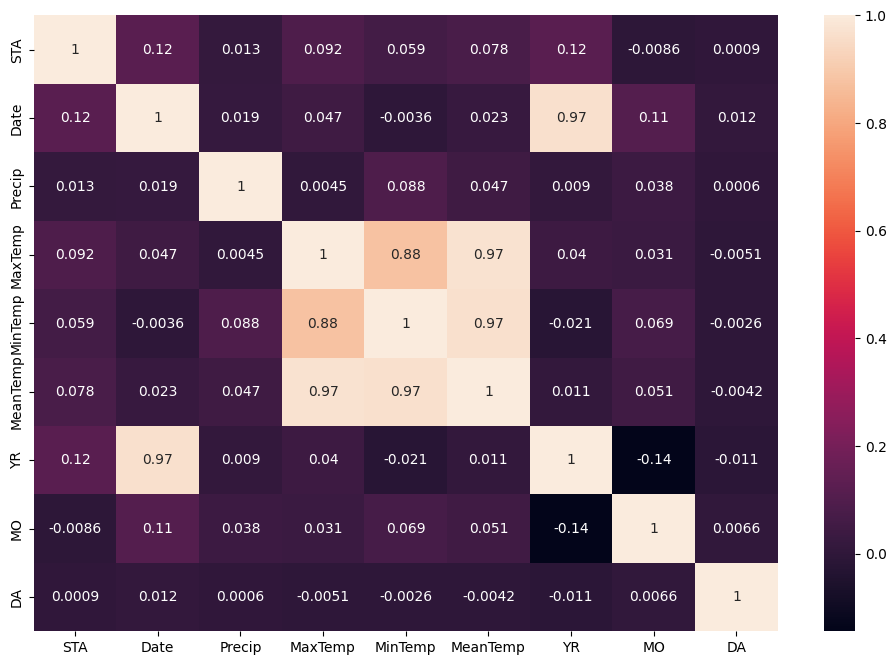

In [25]:
plt.figure(figsize=(12,8))
corr = df.corr()
sns.heatmap(corr, annot=True)
plt.show()

In [26]:
df.columns

Index(['STA', 'Date', 'Precip', 'MaxTemp', 'MinTemp', 'MeanTemp', 'YR', 'MO',
       'DA'],
      dtype='str')

In [27]:
cols = ["MaxTemp", "MinTemp", "MeanTemp"]
df = df[cols]

In [28]:
df

,MaxTemp,MinTemp,MeanTemp
0,25.555556,22.222222,23.888889
1,28.888889,21.666667,25.555556
2,26.111111,22.222222,24.444444
3,26.666667,22.222222,24.444444
4,26.666667,21.666667,24.444444
...,...,...,...
119035,28.333333,18.333333,23.333333
119036,29.444444,18.333333,23.888889
119037,28.333333,18.333333,23.333333
119038,28.333333,18.333333,23.333333


In [29]:
#features
X = df[["MaxTemp", "MinTemp"]]

In [30]:
#target
y = df[["MeanTemp"]]

In [31]:
X.head()

,MaxTemp,MinTemp
0,25.555556,22.222222
1,28.888889,21.666667
2,26.111111,22.222222
3,26.666667,22.222222
4,26.666667,21.666667


In [32]:
y.head()

,MeanTemp
0,23.888889
1,25.555556
2,24.444444
3,24.444444
4,24.444444


In [33]:
from sklearn.model_selection import train_test_split

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X,y,train_size=0.20, random_state=15)

In [35]:
X_train.shape

(23808, 2)

In [36]:
X_test.shape

(95232, 2)

In [37]:
from sklearn.preprocessing import StandardScaler

In [38]:
scaler = StandardScaler()

In [39]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [40]:
X_train_scaled

array([[-2.24644312, -1.71553293],
       [-2.75141718, -2.37822025],
       [-0.10030336,  0.60387271],
       ...,
       [ 0.53091422,  0.60387271],
       [ 0.15218367,  0.20626032],
       [ 0.4046707 ,  0.53760398]], shape=(23808, 2))

In [41]:
X_test_scaled

array([[ 0.02594016,  0.40506651],
       [ 0.27842719,  0.40506651],
       [ 0.78340125,  0.73641018],
       ...,
       [ 0.34154895,  0.53760398],
       [ 0.08906192,  0.53760398],
       [-0.0371816 ,  0.53760398]], shape=(95232, 2))

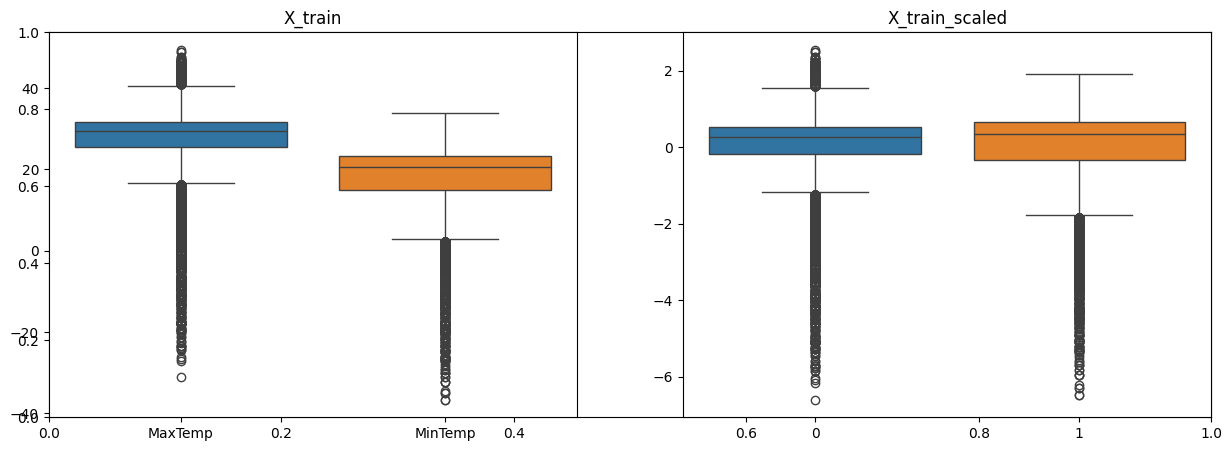

In [42]:
plt.subplots(figsize=(15,5))
plt.subplot(1,2,1)
sns.boxplot(data=X_train)
plt.title("X_train")
plt.subplot(1,2,2)
sns.boxplot(data=X_train_scaled)
plt.title("X_train_scaled")
plt.show()

In [43]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

Mean Absolute Error:  0.17075538371129265
Mean Square Error:  0.2661265619296655
R2 Score:  0.9961194163765741


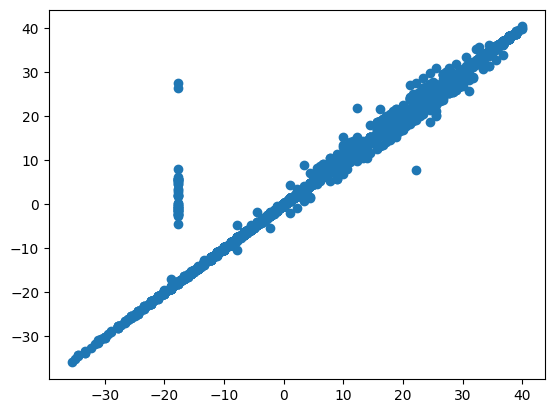

In [52]:
linear = LinearRegression()
linear.fit(X_train_scaled, y_train)
y_pred = linear.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
score = r2_score(y_test, y_pred)
print("Mean Absolute Error: " , mae)
print("Mean Square Error: " , mse)
print("R2 Score: " , score)
plt.scatter(y_test,y_pred)
plt.show()


In [45]:
X_new = np.array([[30, 20]])
X_new_scaled = scaler.transform(X_new)
pred = linear.predict(X_new_scaled)
print("Predict MeanTemp:", pred[0][0])

Predict MeanTemp: 25.00591138981007


c:\Users\user\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Mean Absolute Error:  0.7451046319640804
Mean Square Error:  1.3046321604554865
R2 Score:  0.9809762161290899


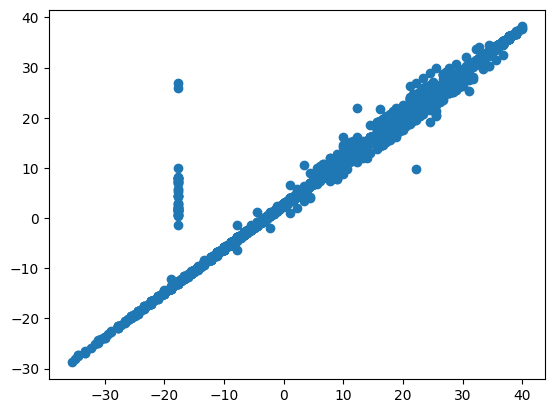

In [53]:
from sklearn.linear_model import Lasso
lasso = Lasso()
lasso.fit(X_train_scaled, y_train)
y_pred = lasso.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
score = r2_score(y_test, y_pred)
print("Mean Absolute Error: " , mae)
print("Mean Square Error: " , mse)
print("R2 Score: " , score)
plt.scatter(y_test,y_pred)
plt.show()


Mean Absolute Error:  0.17072172521834483
Mean Squared Error:  0.26612400655420526
R2 Score:  0.9961194536383494


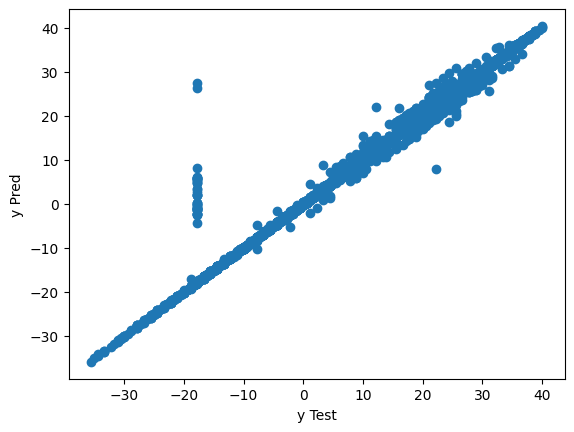

In [54]:
from sklearn.linear_model import Ridge
ridge = Ridge()
ridge.fit(X_train_scaled, y_train)
y_pred = ridge.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
score = r2_score(y_test, y_pred)
print("Mean Absolute Error: ", mae)
print("Mean Squared Error: ", mse)
print("R2 Score: ", score)
plt.scatter(y_test,y_pred)
plt.xlabel("y Test")
plt.ylabel("y Pred")
plt.show()

Mean Absolute Error:  1.519444343209041
Mean Squared Error:  4.840380635289294
R2 Score:  0.9294189137369316


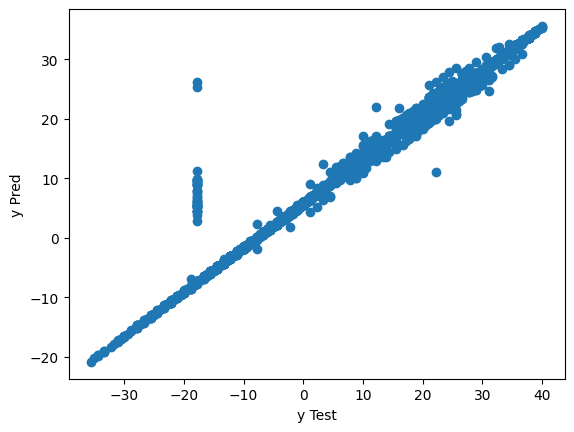

In [55]:
from sklearn.linear_model import ElasticNet
elasticnet = ElasticNet()
elasticnet.fit(X_train_scaled, y_train)
y_pred = elasticnet.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
score = r2_score(y_test, y_pred)
print("Mean Absolute Error: ", mae)
print("Mean Squared Error: ", mse)
print("R2 Score: ", score)
plt.scatter(y_test,y_pred)
plt.xlabel("y Test")
plt.ylabel("y Pred")
plt.show()

c:\Users\user\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1756: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Mean Absolute Error:  0.17087081365904652
Mean Squared Error:  0.2675523457729542
R2 Score:  0.9960986259925076


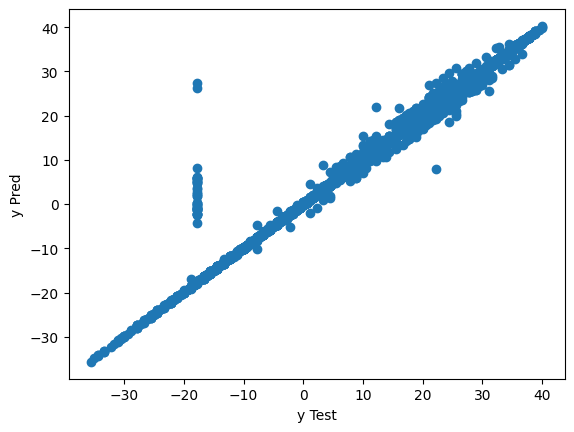

In [56]:
from sklearn.linear_model import ElasticNetCV
elasticnetcv = ElasticNetCV(cv=5)
elasticnetcv.fit(X_train_scaled, y_train)
y_pred = elasticnetcv.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
score = r2_score(y_test, y_pred)
print("Mean Absolute Error: ", mae)
print("Mean Squared Error: ", mse)
print("R2 Score: ", score)
plt.scatter(y_test,y_pred)
plt.xlabel("y Test")
plt.ylabel("y Pred")
plt.show()

In [50]:
results = pd.DataFrame(
    X_test_scaled, columns=["MaxTemp_scaled", "MinTemp_scaled"]
)
results["y_test"] = y_test.values.ravel()
results["y_pred"] = y_pred
results.head()

,MaxTemp_scaled,MinTemp_scaled,y_test,y_pred
0,0.025940,0.405067,23.888889,24.132965
1,0.278427,0.405067,25.555556,25.256420
2,0.783401,0.736410,28.888889,28.868366
3,-2.246443,-2.510758,2.222222,2.009549
4,-0.037182,0.537604,24.444444,24.398116
